# <p align =center> *End to End KPI Framework for E-commerce operations*

---

### Import necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import datasets

In [ ]:
pd.set_option('display.max_columns', None) # Show all columns in the DataFrame
df1 = pd.read_csv('olist_orders_dataset.csv', encoding='utf-8')
df2 = pd.read_csv('olist_order_items_dataset.csv', encoding='utf-8')
df3 = pd.read_csv('olist_products_dataset.csv', encoding='utf-8')
df4 = pd.read_csv('olist_order_reviews_dataset.csv', encoding='utf-8')
df5 = pd.read_csv('product_category_name_translation.csv', encoding='utf-8')

---

### Data Understanding

#### Olist orders dataset

In [ ]:
df1.head() # Display the first few rows of the orders dataset

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [28]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
df1.duplicated().sum() # Check for duplicate rows in the orders dataset

0

#### Olist order items dataset

In [ ]:
df2.head() # Display the first few rows of the order items dataset

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
df2.info() # Check the structure and data types of the order items dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [ ]:
df2.duplicated().sum() # Check for duplicate rows in the order items dataset

0

#### Olist products dataset

In [21]:
df3.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [34]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [36]:
df3.duplicated().sum()

0

#### Olist products reviews dataset

In [22]:
df4.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,ParabÃ©ns lojas lannister adorei comprar pela ...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [35]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [37]:
df4.duplicated().sum()

0

#### Product category name translations dataset

In [25]:
df5.head(5)

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [38]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


---

### Data Structuring and Visualisations

In [ ]:
df_full  = df1.merge( # Merge orders with order items
    df2, on='order_id', how='right').merge(
        df3, on='product_id', how='left').merge(
            df4, on='order_id', how='left').merge(
                df5, on='product_category_name', how='left')

df_full.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,97ca439bc427b48bc1cd7177abe71365,5.0,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,2017-09-22 10:57:03,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,7b07bacd811c4117b742569b04ce3580,4.0,NaN,NaN,2017-05-13 00:00:00,2017-05-15 11:34:13,pet_shop
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,0c5b33dea94867d1ac402749e5438e8b,5.0,NaN,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,2018-01-23 16:06:31,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,f4028d019cb58564807486a6aaf33817,4.0,NaN,NaN,2018-08-15 00:00:00,2018-08-15 16:39:01,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,940144190dcba6351888cafa43f3a3a5,5.0,NaN,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,2017-03-03 10:54:59,garden_tools


In [ ]:
df_full.info() # Check the structure and data types of the merged dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113314 entries, 0 to 113313
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113314 non-null  object 
 1   customer_id                    113314 non-null  object 
 2   order_status                   113314 non-null  object 
 3   order_purchase_timestamp       113314 non-null  object 
 4   order_approved_at              113299 non-null  object 
 5   order_delivered_carrier_date   112111 non-null  object 
 6   order_delivered_customer_date  110839 non-null  object 
 7   order_estimated_delivery_date  113314 non-null  object 
 8   order_item_id                  113314 non-null  int64  
 9   product_id                     113314 non-null  object 
 10  seller_id                      113314 non-null  object 
 11  shipping_limit_date            113314 non-null  object 
 12  price                         

In [ ]:
df_full.duplicated().sum() # Check for duplicate rows in the merged dataset

0

In [ ]:
df_full['order_status'].value_counts() # Check the distribution of order statuses

order_status
delivered      110840
shipped          1196
canceled          546
invoiced          364
processing        358
unavailable         7
approved            3
Name: count, dtype: int64

In [ ]:
df_full = df_full[df_full['order_status'] == 'delivered'] # Filter the dataset to include only delivered orders

In [ ]:
df_full.shape # Check the shape of the filtered dataset

(110840, 29)

In [ ]:
df_full.size # Check the total number of elements in the filtered dataset

3214360

In [ ]:
df_full.info() # Check the structure and data types of the merged dataset

<class 'pandas.core.frame.DataFrame'>
Index: 110840 entries, 0 to 113313
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       110840 non-null  object 
 1   customer_id                    110840 non-null  object 
 2   order_status                   110840 non-null  object 
 3   order_purchase_timestamp       110840 non-null  object 
 4   order_approved_at              110825 non-null  object 
 5   order_delivered_carrier_date   110838 non-null  object 
 6   order_delivered_customer_date  110832 non-null  object 
 7   order_estimated_delivery_date  110840 non-null  object 
 8   order_item_id                  110840 non-null  int64  
 9   product_id                     110840 non-null  object 
 10  seller_id                      110840 non-null  object 
 11  shipping_limit_date            110840 non-null  object 
 12  price                          1108

In [ ]:
df_full.head() # Display the first few rows of the final merged and filtered dataset

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,97ca439bc427b48bc1cd7177abe71365,5.0,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,2017-09-22 10:57:03,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,7b07bacd811c4117b742569b04ce3580,4.0,NaN,NaN,2017-05-13 00:00:00,2017-05-15 11:34:13,pet_shop
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,0c5b33dea94867d1ac402749e5438e8b,5.0,NaN,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,2018-01-23 16:06:31,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,f4028d019cb58564807486a6aaf33817,4.0,NaN,NaN,2018-08-15 00:00:00,2018-08-15 16:39:01,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,940144190dcba6351888cafa43f3a3a5,5.0,NaN,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,2017-03-03 10:54:59,garden_tools


In [53]:
df_full['review_comment_title'].isnull().sum()

97710

In [54]:
df_full['review_comment_title'].value_counts()

review_comment_title
Recomendo                    471
recomendo                    389
Bom                          318
super recomendo              307
Excelente                    281
                            ... 
Entregou antes do prazo        1
FOI TUDO BEM                   1
Adorei o produto..             1
chegou antes do prazo!!!       1
plenamente satisfeita          1
Name: count, Length: 4365, dtype: int64

In [ ]:
df_full.drop(columns=['review_comment_title',  # Drop unnecessary columns
                      'review_comment_message', 'review_creation_date',
                      'review_answer_timestamp','product_name_lenght','product_description_lenght',
                      'product_length_cm','product_height_cm',
                      'product_width_cm','product_photos_qty','product_category_name', 'product_weight_g'], inplace=True)

#### KPI Framework

In [67]:
df_full.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,review_id,review_score,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,97ca439bc427b48bc1cd7177abe71365,5.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,7b07bacd811c4117b742569b04ce3580,4.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,0c5b33dea94867d1ac402749e5438e8b,5.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,f4028d019cb58564807486a6aaf33817,4.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,940144190dcba6351888cafa43f3a3a5,5.0,garden_tools


In [ ]:
Total_Revenue = df_full['price'].sum() # Calculate total revenue by summing the price column
Avg_Delivery_Time = (pd.to_datetime(df_full['order_delivered_customer_date']) - pd.to_datetime(df_full['order_purchase_timestamp'])).mean() # Calculate average delivery time by finding the difference between delivery date and purchase date, then taking the mean
Avg_Review_Score = df_full['review_score'].mean()# Calculate average review score by taking the mean of the review_score column
AOV = Total_Revenue / df_full['order_id'].nunique() # Calculate average order value by dividing total revenue by the number of unique orders
print(f''' # Print the calculated KPIs
Total Revenue: {Total_Revenue}
Average Delivery Time: {Avg_Delivery_Time}
Average Review Score: {Avg_Review_Score}
Average Order Value: {AOV}
''')



Total Revenue: 13651923.47
Average Delivery Time: 12 days 11:27:12.545069876
Average Review Score: 4.032472502046773
Average Order Value: 138.36502412178461



In [185]:
KPI_overall = df_full[['price', 'review_score', 'order_delivered_customer_date', 'order_purchase_timestamp', 'product_category_name_english','order_id']].copy()
KPI_overall['delivery_time'] = pd.to_datetime(KPI_overall['order_delivered_customer_date']) - pd.to_datetime(KPI_overall['order_purchase_timestamp'])
KPI_overall['month'] = pd.to_datetime(KPI_overall['order_purchase_timestamp']).dt.month_name()
KPI_overall.drop(columns=['order_delivered_customer_date'], inplace=True)
KPI_overall.head()

,price,review_score,order_purchase_timestamp,product_category_name_english,order_id,delivery_time,month
0,58.90,5.0,2017-09-13 08:59:02,cool_stuff,00010242fe8c5a6d1ba2dd792cb16214,7 days 14:44:46,September
1,239.90,4.0,2017-04-26 10:53:06,pet_shop,00018f77f2f0320c557190d7a144bdd3,16 days 05:11:18,April
2,199.00,5.0,2018-01-14 14:33:31,furniture_decor,000229ec398224ef6ca0657da4fc703e,7 days 22:45:45,January
3,12.99,4.0,2018-08-08 10:00:35,perfumery,00024acbcdf0a6daa1e931b038114c75,6 days 03:32:04,August
4,199.90,5.0,2017-02-04 13:57:51,garden_tools,00042b26cf59d7ce69dfabb4e55b4fd9,25 days 02:44:40,February


In [186]:
KPI_overall.dtypes

price                                    float64
review_score                             float64
order_purchase_timestamp                  object
product_category_name_english             object
order_id                                  object
delivery_time                    timedelta64[ns]
month                                     object
dtype: object

In [187]:
KPI_overall.shape # Check the shape of the KPI_overall DataFrame

(113314, 7)

In [ ]:
KPI = KPI_overall.groupby( # Group the KPI_overall DataFrame by product category and month, then calculate the KPIs for each group
    ['product_category_name_english', 'month']
).agg(
    Total_Revenue=('price', 'sum'),
    Avg_Review_Score=('review_score', 'mean'),
    Avg_Delivery_Time=('delivery_time', 'mean'),
    Total_Orders=('product_category_name_english', 'nunique')
).reset_index()
KPI.head()

,product_category_name_english,month,Total_Revenue,Avg_Review_Score,Avg_Delivery_Time,Total_Orders
0,agro_industry_and_commerce,April,4500.70,4.000000,12 days 04:56:36.666666666,1
1,agro_industry_and_commerce,August,5109.09,4.000000,9 days 00:28:52.727272727,1
2,agro_industry_and_commerce,December,5291.70,4.636364,12 days 11:26:32.090909090,1
3,agro_industry_and_commerce,February,7629.64,4.117647,15 days 21:44:02.545454545,1
4,agro_industry_and_commerce,January,5919.41,4.476190,12 days 17:56:35.857142857,1


In [ ]:
KPI['AOV'] = KPI['Total_Revenue'] / KPI['Total_Orders'] # Calculate average order value for each group by dividing total revenue by total orders
KPI.head()

,product_category_name_english,month,Total_Revenue,Avg_Review_Score,Avg_Delivery_Time,Total_Orders,AOV
0,agro_industry_and_commerce,April,4500.70,4.000000,12 days 04:56:36.666666666,1,4500.70
1,agro_industry_and_commerce,August,5109.09,4.000000,9 days 00:28:52.727272727,1,5109.09
2,agro_industry_and_commerce,December,5291.70,4.636364,12 days 11:26:32.090909090,1,5291.70
3,agro_industry_and_commerce,February,7629.64,4.117647,15 days 21:44:02.545454545,1,7629.64
4,agro_industry_and_commerce,January,5919.41,4.476190,12 days 17:56:35.857142857,1,5919.41


#### *Top 5 Categories by Revenue*

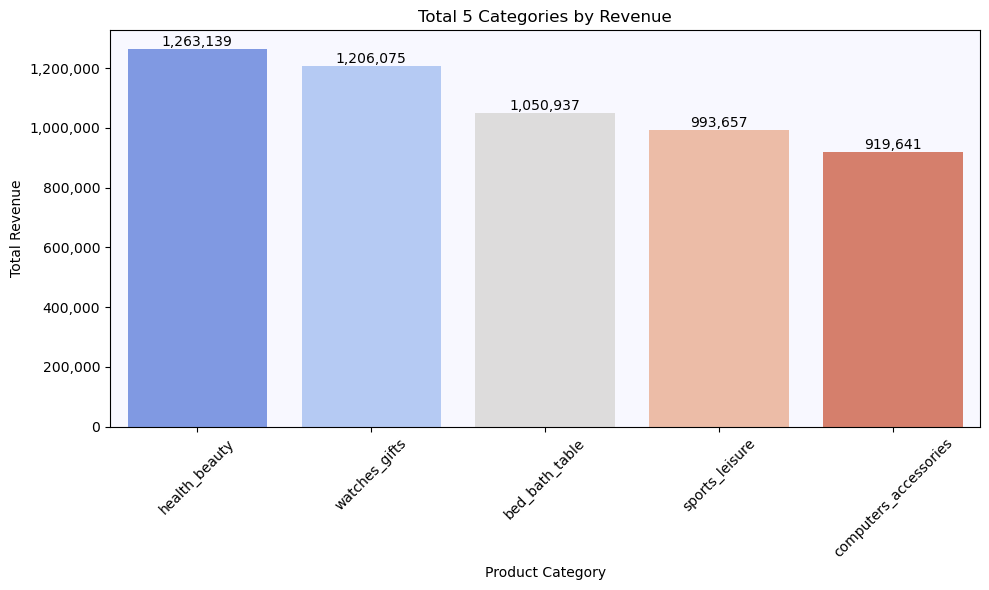

In [ ]:
from matplotlib.ticker import FuncFormatter # For formatting y-axis labels with commas

Top_5_categories_by_revenue = ( # Calculate total revenue for each product category, sort in descending order, and select the top 5 categories
    KPI.groupby('product_category_name_english')['Total_Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

fig, ax = plt.subplots(figsize=(10, 6)) # Create a bar plot to visualize the total revenue for the top 5 product categories

sns.barplot( # Create a bar plot using seaborn
    x=Top_5_categories_by_revenue.index,
    y=Top_5_categories_by_revenue.values,
    hue=Top_5_categories_by_revenue.index,
    palette='coolwarm',
    legend=False
)

for bar in ax.patches: # Annotate each bar with its height (total revenue) formatted with commas
    ax.annotate(
        f'{bar.get_height():,.0f}', # Format the height of the bar with commas and no decimal places
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom'
    )

ax.set_title('Total 5 Categories by Revenue')
ax.set_xlabel('Product Category')
ax.set_ylabel('Total Revenue')

plt.xticks(rotation=45) # Rotate x-axis labels for better readability

ax.yaxis.set_major_formatter( # Format y-axis labels with commas
    FuncFormatter(lambda y, _: f'{y:,.0f}') # Format the y-axis labels with commas and no decimal places
)

ax.set_facecolor('#F8F8FF') # Set the background color of the plot to a light shade for better aesthetics

plt.tight_layout() # Adjust the layout to prevent overlap of elements
plt.show()

#### *Bottom 5 Categories by Revenue*

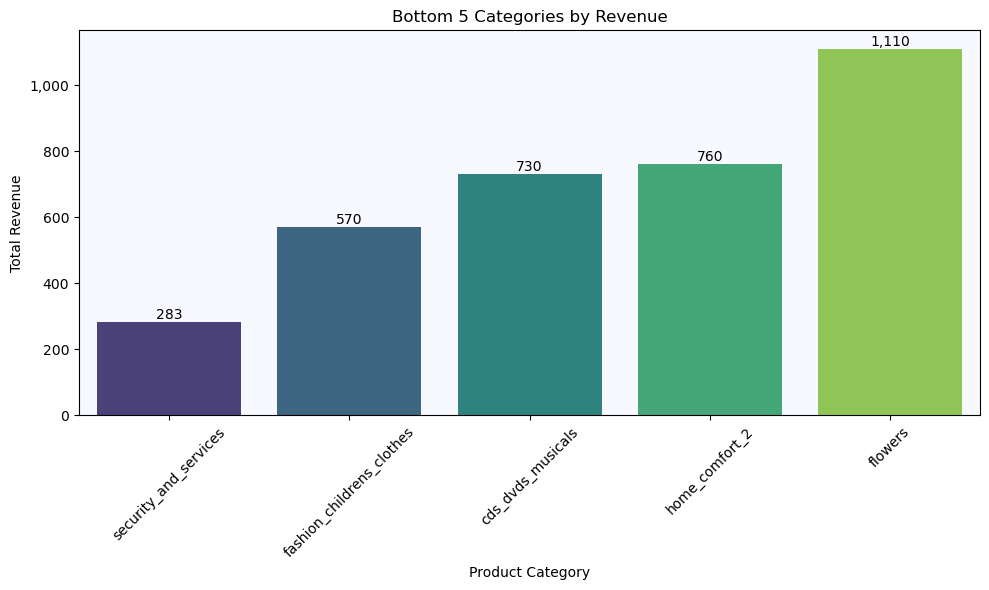

In [ ]:
from matplotlib.ticker import FuncFormatter # For formatting y-axis labels with commas

Bottom_5_categories_by_revenue = ( # Calculate total revenue for each product category, sort in ascending order, and select the bottom 5 categories
    KPI.groupby('product_category_name_english')['Total_Revenue']
    .sum()
    .sort_values(ascending=True)
    .head(5)
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    x=Bottom_5_categories_by_revenue.index,
    y=Bottom_5_categories_by_revenue.values,
    hue=Bottom_5_categories_by_revenue.index,
    palette='viridis',
    legend=False
)

for bar in ax.patches:
    ax.annotate(
        f'{bar.get_height():,.0f}',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom'
    )

ax.set_title('Bottom 5 Categories by Revenue')
ax.set_xlabel('Product Category')
ax.set_ylabel('Total Revenue')

plt.xticks(rotation=45)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f'{y:,.0f}')
)

ax.set_facecolor('#F8F8FF')

plt.tight_layout()
plt.show()

#### *Top 5 Product Categories by Average Review Score*

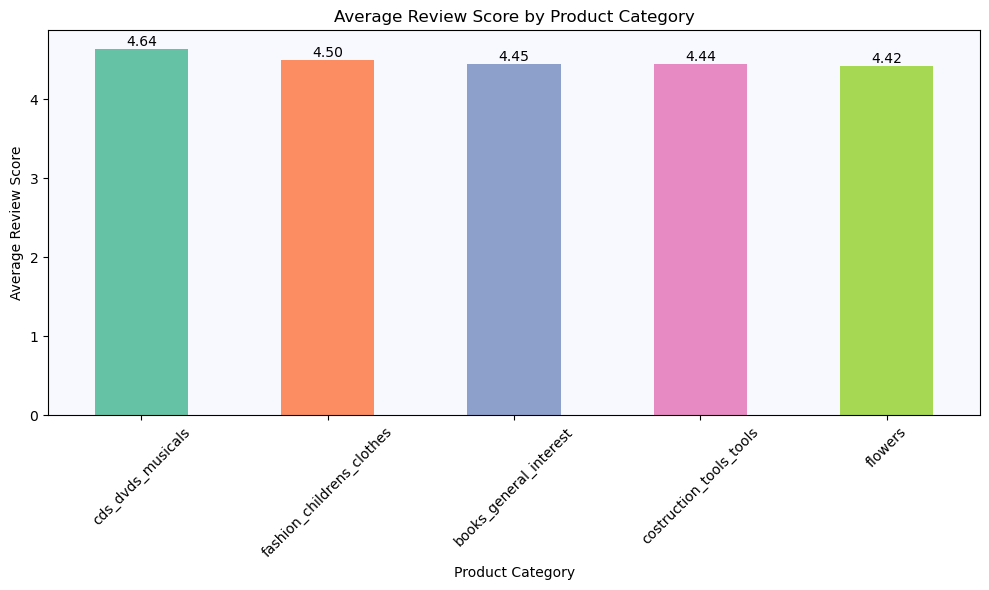

In [ ]:
Top_5_categories_by_revenue = KPI_overall.groupby('product_category_name_english')['review_score'].mean().sort_values(ascending=False).head(5) 
ax = Top_5_categories_by_revenue.plot(kind='bar', figsize=(10, 6), color= sns.color_palette('Set2', n_colors=5))
for x in ax.patches:
    ax.annotate(
        f'{x.get_height():.2f}',
        (x.get_x() + x.get_width() / 2, x.get_height()),
        ha='center',
        va='bottom'
    )
ax.set_facecolor('#F8F8FF')
ax.set_title('Top 5 Product Categories by Average Review Score')
ax.set_xlabel('Product Category')
ax.set_ylabel('Average Review Score')
ax.set_xticklabels(Top_5_categories_by_revenue.index, rotation=45)
plt.tight_layout()
plt.show()


#### *Bottom 5 Product Categories by Average Review Score*

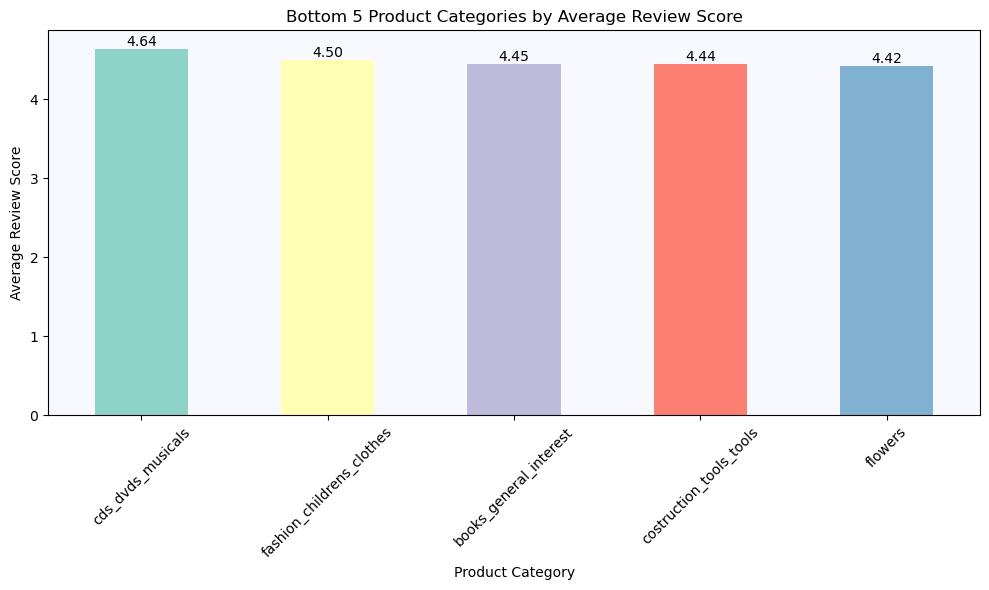

In [139]:
Bottom_5_categories_by_revenue = KPI_overall.groupby('product_category_name_english')['review_score'].mean().sort_values(ascending=False).head(5)
ax = Bottom_5_categories_by_revenue.plot(kind='bar', figsize=(10, 6), color= sns.color_palette('Set3', n_colors=5))
for x in ax.patches:
    ax.annotate(
        f'{x.get_height():.2f}',
        (x.get_x() + x.get_width() / 2, x.get_height()),
        ha='center',
        va='bottom'
    )
ax.set_facecolor('#F8F8FF')
ax.set_title('Bottom 5 Product Categories by Average Review Score')
ax.set_xlabel('Product Category')
ax.set_ylabel('Average Review Score')
ax.set_xticklabels(Bottom_5_categories_by_revenue.index, rotation=45)
plt.tight_layout()
plt.show()

#### *Monthly Revenue Trend*

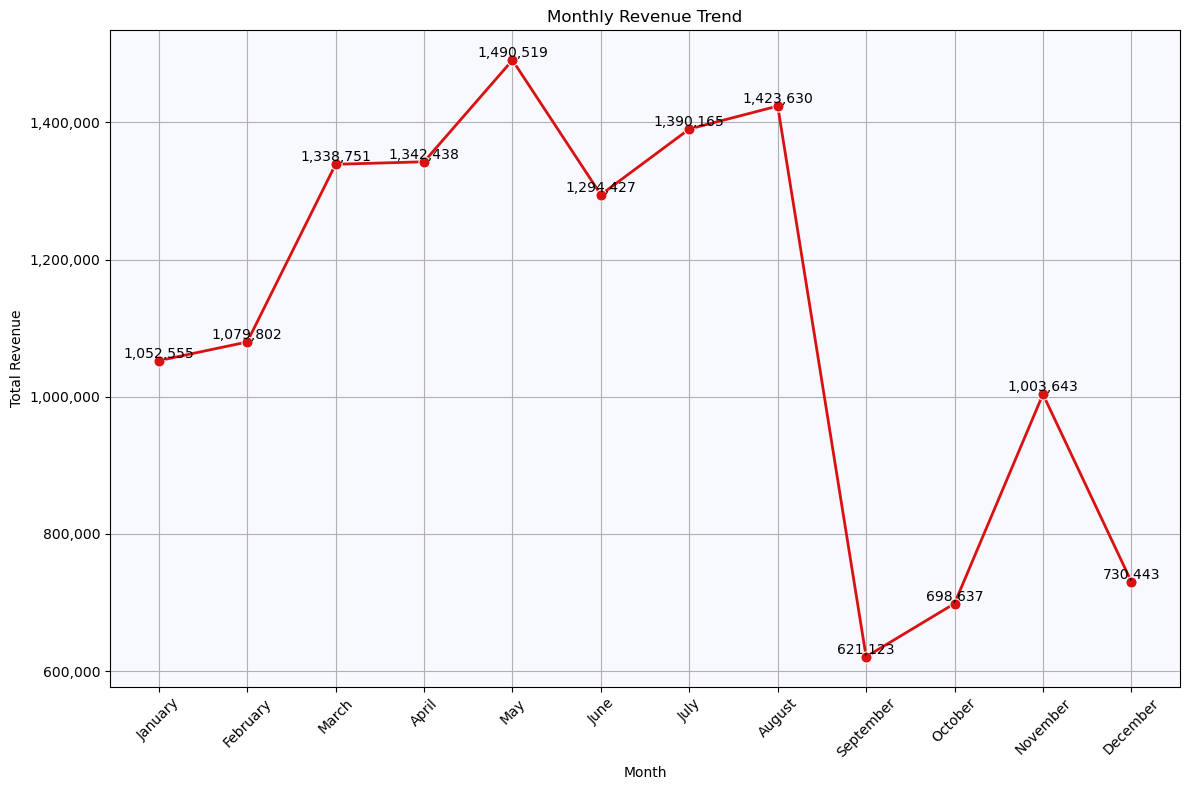

In [ ]:
from matplotlib.ticker import FuncFormatter # For formatting y-axis labels with commas
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]
Monthly_Revenue_Trend = ( # Calculate total revenue for each month by grouping the KPI DataFrame by month and summing the Total_Revenue, then reindex to ensure months are in calendar order
    KPI.groupby('month')['Total_Revenue']
    .sum().reindex(month_order) # Ensure months are in calendar order
)

fig, ax = plt.subplots(figsize=(12, 8))

sns.lineplot( # Create a line plot to visualize the monthly revenue trend
    x=Monthly_Revenue_Trend.index,
    y=Monthly_Revenue_Trend.values,
    marker='o', # Add markers to the line plot for better visibility of data points
    linewidth=2, # Set the line width for better visibility
    markersize=8, # Set the size of the markers for better visibility
    color="#D81111"
)
for x in Monthly_Revenue_Trend.index:
    plt.text(x, Monthly_Revenue_Trend[x], f'{Monthly_Revenue_Trend[x]:,.0f}', ha='center', va='bottom') # Annotate each point on the line plot with its value formatted with commas
ax.set_title('Monthly Revenue Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue')

plt.xticks(rotation=45)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f'{y:,.0f}')
)

ax.set_facecolor('#F8F8FF')
plt.grid()
plt.tight_layout()
plt.show()

#### Seller Level KPI

In [ ]:
Seller_KPI = df_full.groupby('seller_id').agg( # Group the full dataset by seller_id and calculate KPIs for each seller
    Total_Revenue=('price', 'sum'),
    Avg_Review_Score=('review_score', 'mean'),
    Order_count=('order_id', 'nunique')
).reset_index() # Reset index to convert seller_id from index back to a column
Seller_KPI.head()

,seller_id,Total_Revenue,Avg_Review_Score,Order_count
0,0015a82c2db000af6aaaf3ae2ecb0532,2685.00,3.666667,3
1,001cca7ae9ae17fb1caed9dfb1094831,25080.03,3.902542,200
2,001e6ad469a905060d959994f1b41e4f,250.00,1.000000,1
3,002100f778ceb8431b7a1020ff7ab48f,1254.40,3.982143,51
4,003554e2dce176b5555353e4f3555ac8,120.00,5.000000,1


#### *Distribution of Averae Review Score Across Sellers*

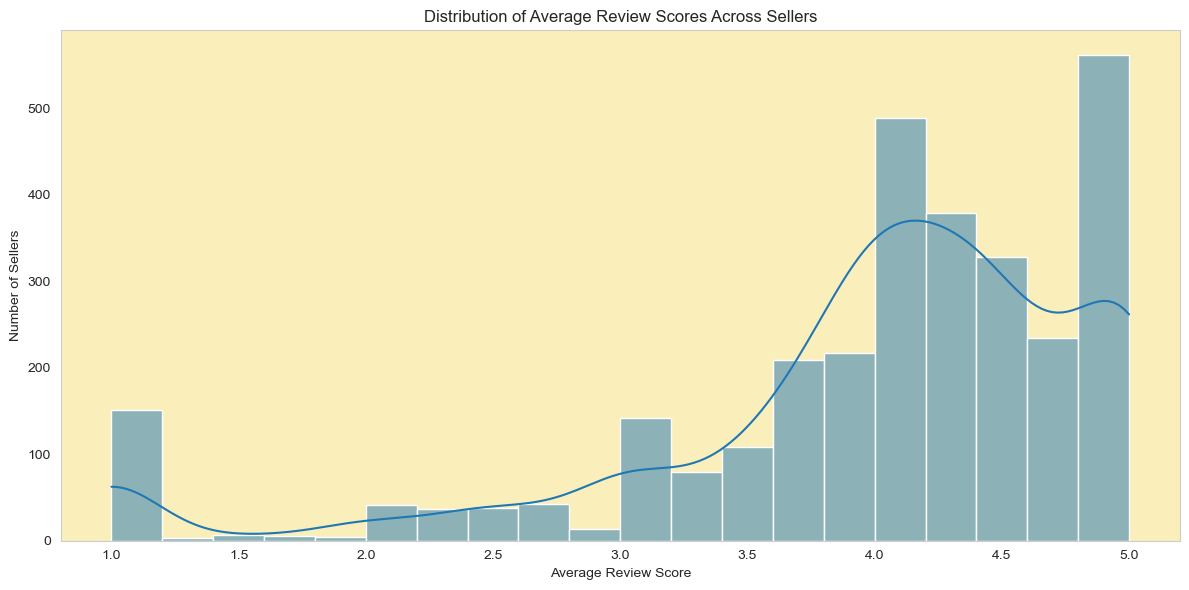

In [ ]:
plt.figure(figsize=(12,6)) # Create a histogram to visualize the distribution of average review scores across sellers
sns.histplot(Seller_KPI['Avg_Review_Score'], bins=20, kde=True) # Create a histogram with a kernel density estimate (KDE) to show the distribution of average review scores across sellers
plt.title('Distribution of Average Review Scores Across Sellers')
plt.xlabel('Average Review Score')
plt.ylabel('Number of Sellers')
plt.gca().set_facecolor("#FAEEBB") # Set the background color of the plot to a light shade for better aesthetics
plt.grid()
plt.tight_layout()
plt.show()

#### Corellation Between Average Delivery Time and Average Review Score per category

In [ ]:
corr_value = KPI['Avg_Delivery_Time'].dt.days.corr(KPI['Avg_Review_Score']) # Calculate correlation between delivery time and review score
print(f'Correlation between Average Delivery Time and Average Review Score: {corr_value:.2f}') # A value close to 1 indicates a strong positive correlation, while a value close to -1 indicates a strong negative correlation.

Correlation between Average Delivery Time and Average Review Score: -0.32


#### *Review score vs Delivery time per category* Scatter Plot

In [156]:
KPI.rename(columns={'product_category_name_english': 'Product Category'}, inplace=True) # Rename the product_category_name_english column to Product Category for better readability in plots and analysis

In [158]:
KPI['Review_Score_Category'] = pd.qcut(KPI['Avg_Review_Score'], q=4, labels=['Risk_products', 'Products_needs_attention', 'Bestseller', 'Vip_product']) # Create quartiles for average review scores to categorize them into Low, Medium, High, and Very High groups
KPI.head()

,Product Category,month,Total_Revenue,Avg_Review_Score,Avg_Delivery_Time,Total_Orders,AOV,Review_Score_Category
0,agro_industry_and_commerce,April,4500.70,4.000000,12 days 04:56:36.666666666,1,4500.70,Products_needs_attention
1,agro_industry_and_commerce,August,5109.09,4.000000,9 days 00:28:52.727272727,1,5109.09,Products_needs_attention
2,agro_industry_and_commerce,December,5291.70,4.636364,12 days 11:26:32.090909090,1,5291.70,Vip_product
3,agro_industry_and_commerce,February,7629.64,4.117647,15 days 21:44:02.545454545,1,7629.64,Bestseller
4,agro_industry_and_commerce,January,5919.41,4.476190,12 days 17:56:35.857142857,1,5919.41,Vip_product


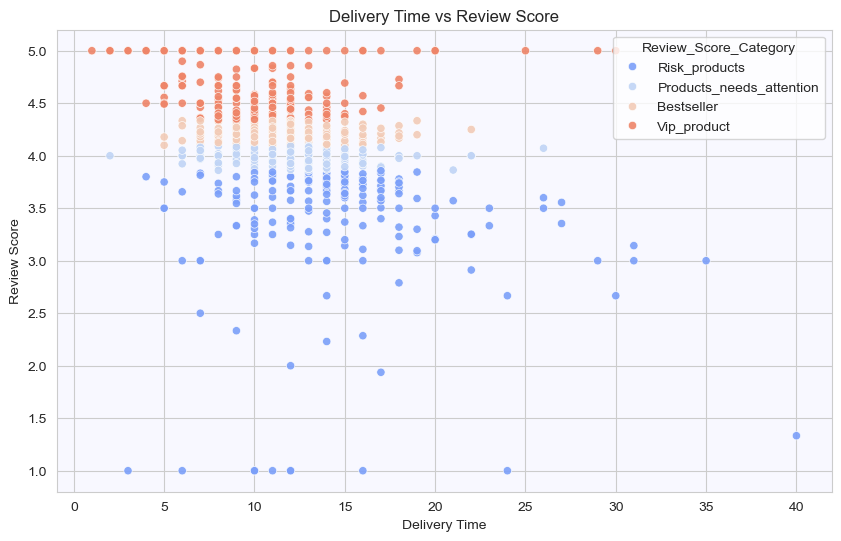

In [169]:
plt.figure(figsize=(10,6)) # Create a scatter plot to visualize the relationship between average delivery time and average review score, colored by product category
sns.scatterplot(data =KPI,x = KPI['Avg_Delivery_Time'].dt.days, y=KPI['Avg_Review_Score'], alpha=0.9, hue=KPI['Review_Score_Category'], palette='coolwarm')
plt.title('Delivery Time vs Review Score')
plt.xlabel('Delivery Time')
plt.ylabel('Review Score')
plt.gca().set_facecolor("#F8F8FF") # Set the background color of the plot to a light shade for better aesthetics

plt.show()

#### Monthly KPI Table

In [190]:
Monthly_KPI_Summary_table = pd.pivot_table(
    KPI_overall,
    index='month',
    values=['price', 'review_score', 'delivery_time'],
    aggfunc={
        'price': 'sum',
        'review_score': 'mean',
        'delivery_time': 'mean'
    }
)
Monthly_KPI_Summary_table['AOV'] = Monthly_KPI_Summary_table['price'] / KPI_overall.groupby('month')['order_id'].nunique() # Calculate average order value for each month by dividing total revenue by the number of unique orders in that month
Monthly_KPI_Summary_table = Monthly_KPI_Summary_table.reindex(month_order) # Reindex the summary table to ensure months are in calendar order
Monthly_KPI_Summary_table.rename(columns={'price': 'Total Revenue', 'review_score': 'Average Review Score', 'delivery_time': 'Average Delivery Time'}, inplace=True) # Rename columns for better readability
Monthly_KPI_Summary_table['Product_Category'] = KPI_overall.groupby('month')['product_category_name_english'].agg(lambda x: x.mode()[0]) # Add a column for the most common product category in each month
Monthly_KPI_Summary_table.head()

,Average Delivery Time,Total Revenue,Average Review Score,AOV,Product_Category
month,,,,,
January,13 days 22:52:26.842099423,1076746.64,3.963567,134.442083,bed_bath_table
February,16 days 04:12:25.679245283,1102154.23,3.801658,130.788445,computers_accessories
March,15 days 05:15:45.687278025,1362877.75,3.792438,138.658841,bed_bath_table
April,12 days 04:43:37.897551608,1359631.24,4.057796,145.804959,bed_bath_table
May,11 days 08:43:04.357239170,1506706.29,4.133760,143.318395,bed_bath_table


#### *Categories where delivery time is above average AND review score is below average*


In [198]:
import numpy as np
Monthly_KPI_Summary_table['Needs_Attention'] = np.where(
    (Monthly_KPI_Summary_table['Average Delivery Time'].dt.days > Avg_Delivery_Time.days) &
    (Monthly_KPI_Summary_table['Average Review Score'] < Avg_Review_Score),
    '✓',
    'X'
)
Monthly_KPI_Summary_table.head()

,Average Delivery Time,Total Revenue,Average Review Score,AOV,Product_Category,Needs_Attention
month,,,,,,
January,13 days 22:52:26.842099423,1076746.64,3.963567,134.442083,bed_bath_table,✓
February,16 days 04:12:25.679245283,1102154.23,3.801658,130.788445,computers_accessories,✓
March,15 days 05:15:45.687278025,1362877.75,3.792438,138.658841,bed_bath_table,✓
April,12 days 04:43:37.897551608,1359631.24,4.057796,145.804959,bed_bath_table,X
May,11 days 08:43:04.357239170,1506706.29,4.133760,143.318395,bed_bath_table,X


---

### Author : *Huseyn Ahmadov*

---

# <p align =center> *Thanks for your considerations!*